<a href="https://colab.research.google.com/github/amirkalateh/PracticalGrimyKeygenerator/blob/main/t2f_music.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install librosa matplotlib numpy

در حال پردازش فایل، لطفاً چند ثانیه منتظر بمانید...
در حال محاسبه BPM و پیدا کردن ضرب‌ها...
در حال تحلیل داینامیک و انرژی صدا...

نتایج آنالیز:
🎵 تمپو (BPM): 114.84
🥁 تعداد کل ضرب‌ها: 713
⏱ زمان کل موزیک: 439.80 ثانیه



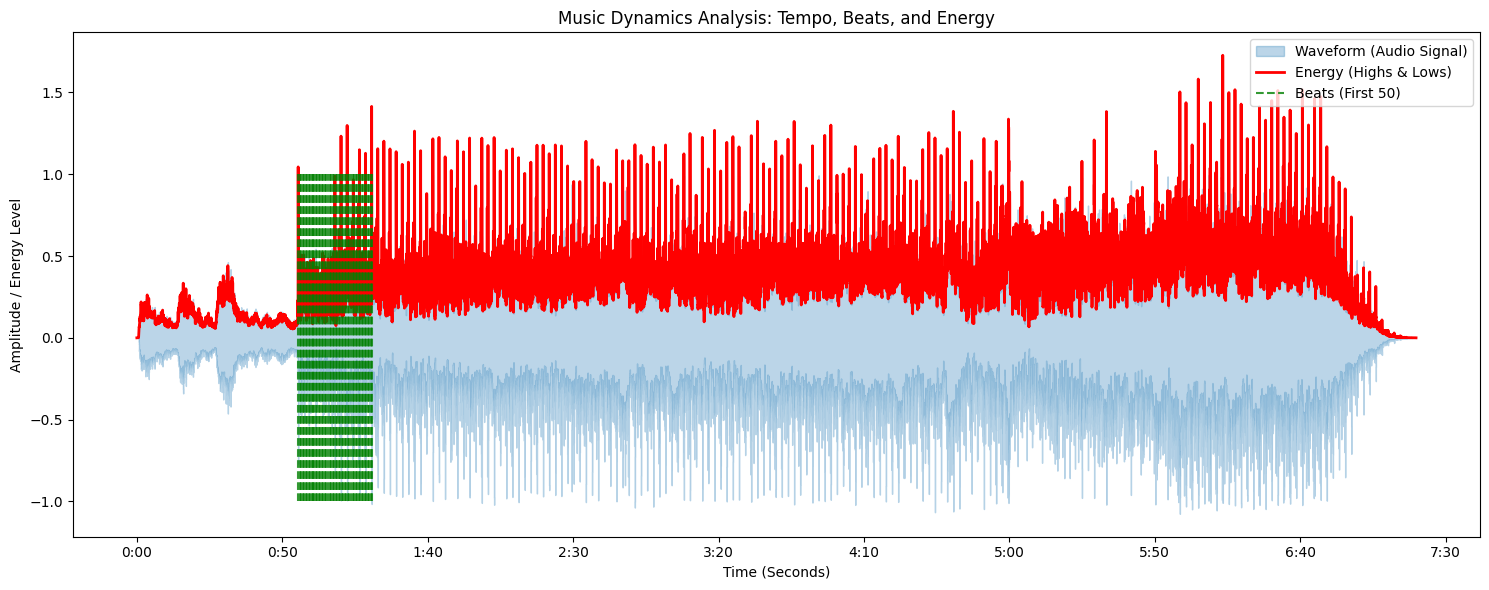

In [3]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

def analyze_music(file_path):
    """
    آنالیز فایل صوتی (MP3/WAV) برای استخراج تمپو و انرژی (اوج و فرود)
    """
    print("در حال پردازش فایل، لطفاً چند ثانیه منتظر بمانید...")

    # ۱. بارگذاری فایل صوتی
    # استفاده از sr=None باعث می‌شود موزیک با کیفیت اصلی خودش (بدون تغییر سمپل‌ریت) لود شود
    y, sr = librosa.load(file_path, sr=None)

    # ۲. محاسبه تمپو (BPM) و موقعیت ضرب‌ها
    print("در حال محاسبه BPM و پیدا کردن ضرب‌ها...")
    tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr)

    # تبدیل شماره فریم‌ها به آرایه‌ای از ثانیه‌ها (برای استفاده در منطق برنامه‌نویسی)
    beat_times = librosa.frames_to_time(beat_frames, sr=sr)

    # ۳. محاسبه انرژی (RMS) برای تشخیص بخش‌های خلوت و شلوغ (بالا و پایین شدن موزیک)
    print("در حال تحلیل داینامیک و انرژی صدا...")
    rms = librosa.feature.rms(y=y)[0]

    # تولید آرایه زمانی متناظر با فریم‌های RMS
    times = librosa.frames_to_time(np.arange(len(rms)), sr=sr)

    print("\n" + "="*30)
    print("نتایج آنالیز:")
    # به دلیل تغییرات نسخه‌های جدید librosa، تمپو ممکن است یک آرایه تک‌عضوی باشد
    bpm_value = tempo[0] if isinstance(tempo, np.ndarray) else tempo
    print(f"🎵 تمپو (BPM): {bpm_value:.2f}")
    print(f"🥁 تعداد کل ضرب‌ها: {len(beat_times)}")
    print(f"⏱ زمان کل موزیک: {librosa.get_duration(y=y, sr=sr):.2f} ثانیه")
    print("="*30 + "\n")

    # ۴. رسم نمودار بصری برای درک بهتر داده‌ها
    plt.figure(figsize=(15, 6))

    # نمایش شکل موج اصلی صدا (کمرنگ در پس‌زمینه)
    librosa.display.waveshow(y, sr=sr, alpha=0.3, label='Waveform (Audio Signal)')

    # نمایش منحنی انرژی - ضرب در ۳ شده تا روی نمودار هم‌قدِ شکل‌موج شود و راحت‌تر دیده شود
    plt.plot(times, rms * 3, color='red', linewidth=2, label='Energy (Highs & Lows)')

    # خطوط عمودی برای نمایش بیت‌ها (برای جلوگیری از سیاه شدن نمودار، فقط ۵۰ بیت اول رسم می‌شود)
    plt.vlines(beat_times[:50], -1, 1, color='green', alpha=0.8, linestyle='--', label='Beats (First 50)')

    plt.title('Music Dynamics Analysis: Tempo, Beats, and Energy')
    plt.xlabel('Time (Seconds)')
    plt.ylabel('Amplitude / Energy Level')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    # برگرداندن داده‌ها به صورت یک دیکشنری برای استفاده در API یا پردازش‌های بعدی
    return {
        "bpm": bpm_value,
        "beats_in_seconds": beat_times,
        "energy_levels": rms,
        "time_stamps": times
    }

# ========== نحوه استفاده ==========
if __name__ == "__main__":
    # نام فایل MP3 خود را اینجا قرار دهید (می‌تواند مسیر کامل فایل هم باشد)
    music_file = "test_music.mp3"

    try:
        results = analyze_music(music_file)
        # حالا به راحتی می‌توانید از داده‌ها استفاده کنید
        # مثلا اگر می‌خواهید بدانید در ثانیه ۶۰ام موزیک چقدر انرژی دارد:
        # print(results['energy_levels'])
    except Exception as e:
        print(f"خطا در پردازش فایل: {e}")